In [120]:
import torch
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

In [121]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [122]:
chs = sorted(list(set(''.join(words))))

In [123]:
stoi = {s:i+1 for i,s in enumerate(chs)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [124]:
block_size = 3

def build_dateset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dateset(words[:n1])
Xdev, Ydev = build_dateset(words[n1:n2])
Xte, Yte = build_dateset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [125]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
W1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [126]:
sum(p.nelement() for p in parameters)

11897

In [127]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [128]:
lri = []
lossi = []
stepi = []

In [129]:
emb_view_value = block_size * C.shape[1]
emb_view_value

30

In [135]:
for i in range(100000):
    
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    stepi.append(i)
    lossi.append(loss.log10().item())

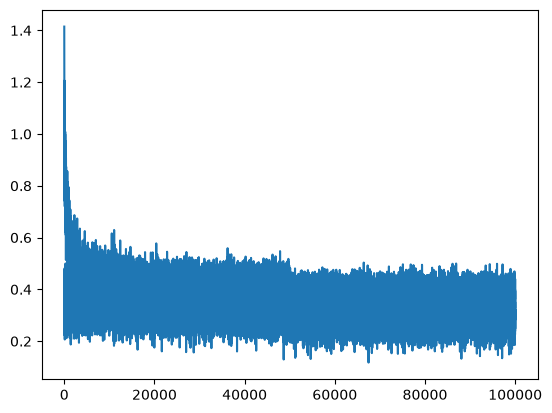

In [136]:
plt.plot(stepi, lossi)

In [137]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,emb_view_value) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.1319668292999268

In [138]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,emb_view_value) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.170382022857666

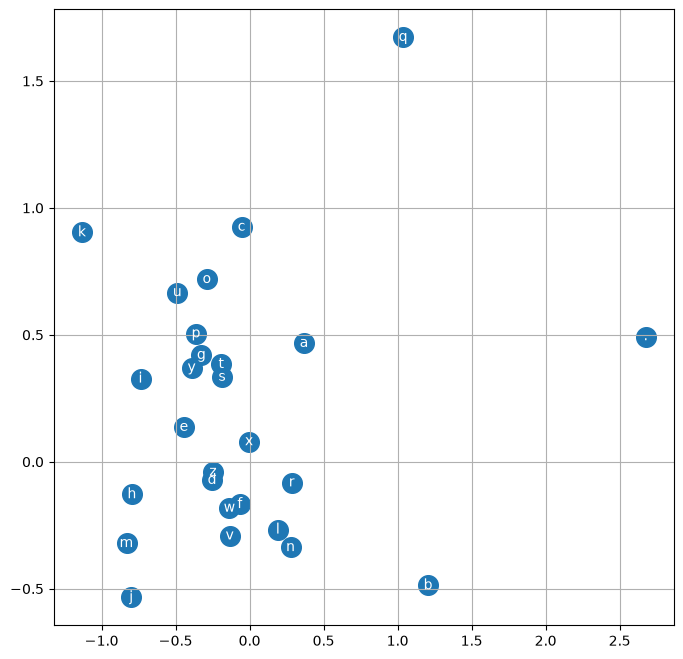

In [139]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [140]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmah.
ambrilli.
kemri.
reviyah.
cassie.
rahnevalperric.
areei.
nellara.
chaiir.
kaleigh.
ham.
pori.
quinn.
sulin.
alvin.
quinathonderryni.
jaxek.
dus.
boed.
edi.
